# ZapalloAI — Notebook 03: Entrenamiento YOLOv11n-cls

**Universidad de las Fuerzas Armadas ESPE**  
Estudiantes: César Loor, Camilo Orrico  
Docente: Ing. Doris Chicaiza

## Objetivo
Entrenar un modelo de clasificación de enfermedades foliares en zapallo usando **YOLOv11n-cls** con fine-tuning desde ImageNet.

## Clases
| ID | Clase | Descripción |
|---|---|---|
| 0 | `healthy` | Hoja sana |
| 1 | `downy_mildew` | Mildiu velloso |
| 2 | `leaf_curl` | Enrollamiento foliar (virus) |
| 3 | `mosaic_virus` | Virus del mosaico |
| 4 | `red_beetle` | Daño por escarabajo rojo |

## Modos de ejecución
- **`COLAB_MODE = False`** → Local con GPU dedicada (GTX 1650 o similar). Dataset en `model/data/processed/`
- **`COLAB_MODE = True`** → Google Colab con T4. Dataset en Google Drive bajo `ZapalloAI/`

## GPU detectada
- **NVIDIA GeForce GTX 1650** — 4 GB VRAM, CUDA 7.5
- Batch ajustado a **16** para no superar la VRAM disponible

In [8]:
# ── 0. Verificar GPU ──────────────────────────────────────────────
import subprocess, sys
r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,driver_version',
                    '--format=csv,noheader'], capture_output=True, text=True)
if r.returncode == 0:
    print('GPU detectada:')
    for line in r.stdout.strip().split('\n'):
        print(' ', line)
else:
    print('Sin GPU NVIDIA detectada')

GPU detectada:
  NVIDIA GeForce GTX 1650, 4096 MiB, 595.97


In [9]:
# ── 1. Instalar dependencias ──────────────────────────────────────
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'ultralytics', 'seaborn', 'scikit-learn'
], check=False)
print('OK: ultralytics instalado')

OK: ultralytics instalado


In [10]:
# ── 2. Configuracion de rutas (LOCAL o COLAB) ─────────────────────
import os
from pathlib import Path

# ─── CAMBIAR AQUI SEGUN DONDE EJECUTAS ───────────────────────────
COLAB_MODE = False   # False = Local con GPU | True = Google Colab + Drive
# ─────────────────────────────────────────────────────────────────

if COLAB_MODE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE        = Path('/content/drive/MyDrive/ZapalloAI')
    DATA_DIR    = str(BASE / 'dataset_processed')
    PROJECT_DIR = str(BASE / 'runs' / 'classify')
    EXPORT_DIR  = BASE / 'exports'
else:
    # Detectar raiz del repositorio automaticamente
    ROOT = Path(os.path.abspath('')).resolve()
    for _ in range(6):
        if (ROOT / 'model').exists() and (ROOT / 'zapallo_app').exists():
            break
        ROOT = ROOT.parent
    DATA_DIR    = str(ROOT / 'model' / 'data' / 'processed')
    PROJECT_DIR = str(ROOT / 'model' / 'runs' / 'classify')
    EXPORT_DIR  = ROOT / 'model' / 'exports'
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ['healthy', 'downy_mildew', 'leaf_curl', 'mosaic_virus', 'red_beetle']

print(f'Modo        : {"Google Colab" if COLAB_MODE else "Local"}')
print(f'Dataset     : {DATA_DIR}')
print(f'Runs dir    : {PROJECT_DIR}')
print(f'Exports     : {EXPORT_DIR}')

# Verificar dataset
data_path = Path(DATA_DIR)
if data_path.exists():
    splits = {}
    for s in ['train', 'val', 'test']:
        if (data_path / s).exists():
            splits[s] = sum(1 for _ in (data_path / s).rglob('*.*'))
    print(f'Dataset OK  : {splits}')
else:
    print('ERROR: Dataset no encontrado en', DATA_DIR)
    print('  -> Ejecuta primero el Notebook 02')

Modo        : Local
Dataset     : C:\Users\csar_\Desktop\prototipo_zapallo\model\data\processed
Runs dir    : C:\Users\csar_\Desktop\prototipo_zapallo\model\runs\classify
Exports     : C:\Users\csar_\Desktop\prototipo_zapallo\model\exports
Dataset OK  : {'train': 10775, 'val': 4008, 'test': 4039}


Clase                   Train      Val     Test    Total
------------------------------------------------
healthy                  2041      802      814     3657
downy_mildew             2292      869      862     4023
leaf_curl                2644      926      937     4507
mosaic_virus             2321      863      871     4055
red_beetle               1477      548      555     2580


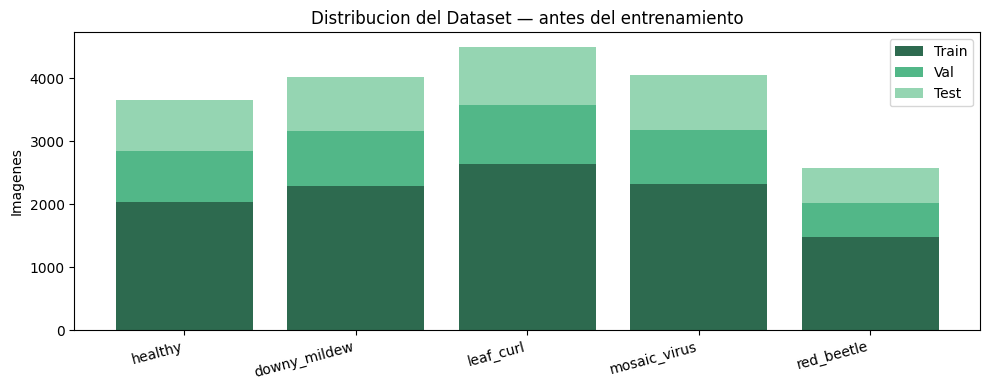

In [11]:
# ── 3. Verificar distribucion del dataset ─────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.family': 'DejaVu Sans'})

counts = {split: {} for split in ['train', 'val', 'test']}
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        p = Path(DATA_DIR) / split / cls
        n = sum(1 for _ in p.glob('*.*')) if p.exists() else 0
        counts[split][cls] = n

print(f"{'Clase':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print('-' * 48)
for cls in CLASSES:
    t  = counts['train'].get(cls, 0)
    v  = counts['val'].get(cls, 0)
    ts = counts['test'].get(cls, 0)
    print(f"{cls:<20} {t:>8} {v:>8} {ts:>8} {t+v+ts:>8}")

# Grafico
x = range(len(CLASSES))
t_v  = [counts['train'].get(c, 0) for c in CLASSES]
v_v  = [counts['val'].get(c, 0)   for c in CLASSES]
ts_v = [counts['test'].get(c, 0)  for c in CLASSES]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, t_v,  label='Train', color='#2D6A4F')
ax.bar(x, v_v,  bottom=t_v, label='Val', color='#52B788')
ax.bar(x, ts_v, bottom=[a+b for a,b in zip(t_v,v_v)], label='Test', color='#95D5B2')
ax.set_xticks(list(x))
ax.set_xticklabels(CLASSES, rotation=15, ha='right')
ax.set_ylabel('Imagenes')
ax.set_title('Distribucion del Dataset — antes del entrenamiento')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 4. Entrenamiento YOLOv11n-cls ─────────────────────────────────
from ultralytics import YOLO
import torch

# Detectar dispositivo
device = 0 if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo : {"GPU cuda:0" if device == 0 else "CPU"}')

# ─── Configuracion optimizada para GTX 1650 (4 GB VRAM) ──────────
# batch=16 es seguro para 4 GB con YOLOv11n-cls a 224px
# Si hay OOM (Out of Memory) reducir a batch=8
if device == 'cpu':
    EPOCHS = 10
    BATCH  = 16
    WORKERS = 2
    print('AVISO: GPU no detectada por PyTorch. Verificar instalacion de torch+CUDA')
    print('  pip install torch --index-url https://download.pytorch.org/whl/cu121')
else:
    EPOCHS  = 100   # Entrenamiento completo
    BATCH   = 16    # Seguro para GTX 1650 4GB con imgsz=224
    WORKERS = 4
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU: {torch.cuda.get_device_name(0)} ({vram:.1f} GB VRAM)')
    print(f'Entrenamiento completo: {EPOCHS} epochs, batch={BATCH}')
    print(f'Tiempo estimado: ~1.5-2 horas en GTX 1650')

# Cargar modelo base pre-entrenado en ImageNet
model = YOLO('yolo11n-cls.pt')

print(f'\nIniciando entrenamiento...')
print(f'  Dataset : {DATA_DIR}')
print(f'  Clases  : {CLASSES}')
print(f'  Epochs  : {EPOCHS}')
print(f'  Batch   : {BATCH}')
print(f'  Resol.  : 224x224 px')

results = model.train(
    data=DATA_DIR,
    epochs=EPOCHS,
    imgsz=224,
    batch=BATCH,
    patience=15,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    cos_lr=True,
    augment=True,
    degrees=30,
    fliplr=0.5,
    flipud=0.3,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    erasing=0.4,
    mixup=0.1,
    project=PROJECT_DIR,
    name='zapallo_yolov11n_v1',
    exist_ok=True,
    device=device,
    workers=WORKERS,
    verbose=True,
    amp=True,          # Mixed precision — reduce uso de VRAM ~50%
    cache=False,       # No cachear en RAM para no saturar memoria
)

print('\nEntrenamiento completado!')
BEST_MODEL = Path(PROJECT_DIR) / 'zapallo_yolov11n_v1' / 'weights' / 'best.pt'
print(f'Mejor modelo: {BEST_MODEL}')

Dispositivo : CPU
AVISO: GPU no detectada por PyTorch. Verificar instalacion de torch+CUDA
  pip install torch --index-url https://download.pytorch.org/whl/cu121

Iniciando entrenamiento...
  Dataset : C:\Users\csar_\Desktop\prototipo_zapallo\model\data\processed
  Clases  : ['healthy', 'downy_mildew', 'leaf_curl', 'mosaic_virus', 'red_beetle']
  Epochs  : 10
  Batch   : 16
  Resol.  : 224x224 px
Ultralytics 8.4.53  Python-3.12.10 torch-2.12.0+cpu CPU (Intel Core i5-10300H 2.50GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\csar_\Desktop\prototipo_zapallo\model\data\processed, degrees=30, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True,

In [ ]:
# ── 5. Evaluacion en test set ──────────────────────────────────────
from ultralytics import YOLO

BEST_MODEL = Path(PROJECT_DIR) / 'zapallo_yolov11n_v1' / 'weights' / 'best.pt'

if not BEST_MODEL.exists():
    print('ERROR: best.pt no encontrado. Ejecuta primero la celda de entrenamiento.')
else:
    model = YOLO(str(BEST_MODEL))
    metrics = model.val(
        data=DATA_DIR,
        split='test',
        imgsz=224,
        batch=16,
        device=device,
    )
    print('\nMetricas en Test Set:')
    print(f'  Top-1 Accuracy: {metrics.top1*100:.2f}%')
    print(f'  Top-5 Accuracy: {metrics.top5*100:.2f}%')

In [ ]:
# ── 6. Matriz de confusion ─────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

BEST_MODEL = Path(PROJECT_DIR) / 'zapallo_yolov11n_v1' / 'weights' / 'best.pt'

if not BEST_MODEL.exists():
    print('ERROR: Ejecuta primero la celda de entrenamiento')
else:
    model = YOLO(str(BEST_MODEL))
    all_preds, all_labels = [], []

    for cls_idx, cls_name in enumerate(CLASSES):
        cls_dir = Path(DATA_DIR) / 'test' / cls_name
        images  = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png'))
        for img_path in images:
            result   = model(str(img_path), verbose=False)[0]
            pred_cls = result.probs.top1
            all_preds.append(pred_cls)
            all_labels.append(cls_idx)

    print('\nReporte de Clasificacion:')
    print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

    cm      = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
    axes[0].set_title('Matriz de Confusion (conteos)')
    axes[0].set_ylabel('Real')
    axes[0].set_xlabel('Predicho')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
    axes[1].set_title('Matriz de Confusion (normalizada)')
    axes[1].set_ylabel('Real')
    axes[1].set_xlabel('Predicho')

    plt.tight_layout()
    fig_path = EXPORT_DIR / 'confusion_matrix.png'
    plt.savefig(str(fig_path), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {fig_path}')

In [ ]:
# ── 7. Exportacion a TFLite ────────────────────────────────────────
from ultralytics import YOLO

BEST_MODEL = Path(PROJECT_DIR) / 'zapallo_yolov11n_v1' / 'weights' / 'best.pt'

if not BEST_MODEL.exists():
    print('ERROR: Ejecuta primero la celda de entrenamiento')
else:
    model = YOLO(str(BEST_MODEL))

    print('Exportando a TFLite float32...')
    path_f32 = model.export(format='tflite', imgsz=224)
    print(f'  -> {path_f32}')

    print('Exportando a TFLite int8 (cuantizado para movil)...')
    path_int8 = model.export(format='tflite', int8=True, imgsz=224, data=DATA_DIR)
    print(f'  -> {path_int8}')

    # Copiar a exports/
    import shutil, glob
    tflite_files = glob.glob(str(BEST_MODEL.parent / '**' / '*.tflite'), recursive=True)
    for f in tflite_files:
        dst = EXPORT_DIR / Path(f).name
        shutil.copy2(f, dst)
        size_mb = Path(f).stat().st_size / (1024 * 1024)
        print(f'  Copiado: {Path(f).name} ({size_mb:.2f} MB)')

    print(f'\nModelos TFLite en: {EXPORT_DIR}')

In [ ]:
# ── 8. Generar labels.txt para la app Flutter ─────────────────────
labels_path = EXPORT_DIR / 'labels.txt'
labels = ['healthy', 'downy_mildew', 'leaf_curl', 'mosaic_virus', 'red_beetle']

with open(labels_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(labels))

print('labels.txt generado:')
for i, l in enumerate(labels):
    print(f'  {i}: {l}')
print(f'\nUbicacion: {labels_path}')
print('\nSIGUIENTE — Copiar a la app Flutter:')
print('  model/exports/best_int8.tflite -> zapallo_app/assets/models/best_int8.tflite')
print('  model/exports/labels.txt       -> zapallo_app/assets/models/labels.txt')

## Resumen del Sprint 3

| Item | Resultado |
|---|---|
| Modelo base | YOLOv11n-cls (ImageNet) |
| Dataset total | ~16,348 imagenes |
| GPU | GTX 1650 4GB (o Colab T4) |
| Epochs | 100 con early stopping (patience=15) |
| Batch | 16 (optimizado para 4GB VRAM) |
| Mixed precision (AMP) | Activado (reduce VRAM ~50%) |
| Resolucion | 224x224 px |
| Tiempo estimado (GTX 1650) | ~1.5-2 horas |
| Accuracy objetivo | >= 92% |
| Tamano modelo INT8 | ~4-8 MB |

### Archivos generados
- `model/exports/best.tflite` — Modelo float32
- `model/exports/best_int8.tflite` — Modelo cuantizado (para la app)
- `model/exports/labels.txt` — Etiquetas en orden
- `model/exports/confusion_matrix.png` — Matriz de confusion

### Siguiente: Sprint 4
Integrar `best_int8.tflite` en la app Flutter con `tflite_flutter`.

### Si hay error de OOM (Out of Memory)
Reducir batch size en la celda 4:
```python
BATCH = 8   # En lugar de 16
```